# Research question 1 — where truck crashes happen, and how many are off-route

> How many vehicle collisions involving trucks happen in NYC? How are they
> distributed around the city, and how often do they happen on versus off
> established truck routes?

This notebook profiles the NYPD collision data for truck involvement and maps
the result against the DOT truck route network.

**Before running:** `python src/collect.py all` and `python src/collect_geo.py all`,
then `python src/routes.py`. Everything below reads cached files.

**Definition of "truck" is a judgment call and it moves the headline.** The
curated code list is in `src/vehicle_codes.py`, split into a core tier of
unambiguous heavy goods vehicles and a light-commercial tier reported
separately. The list is published with the analysis for exactly this reason.

Findings are recorded in `research/research-log.md`; what they cannot support
is in `research/limitations.md`.

In [13]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

import viz
from constants import EXTERNAL_FILES, PROCESSED_DIR, ROUTE_BUFFER_M

viz.use_style()
METRIC_CRS = 32618

points = pd.read_parquet(PROCESSED_DIR / "crash_points.parquet")
routes = gpd.read_file(EXTERNAL_FILES["truck_routes"]).to_crs(METRIC_CRS)
boroughs = gpd.read_file(EXTERNAL_FILES["boroughs"]).to_crs(METRIC_CRS)

# Project the crash points once; every map below reuses these coordinates.
geo = gpd.GeoDataFrame(
    points,
    geometry=gpd.points_from_xy(points.longitude, points.latitude),
    crs=4326,
).to_crs(METRIC_CRS)
geo["x"], geo["y"] = geo.geometry.x, geo.geometry.y

truck = geo[geo.is_truck_core]
print(f"{len(geo):,} geocoded crashes since 2016")
print(f"{len(truck):,} of them involve a truck (core list)  "
      f"= {len(truck)/len(geo):.2%}")

1,407,499 geocoded crashes since 2016
110,445 of them involve a truck (core list)  = 7.85%


## 1. How many truck crashes?

The count and the share answer different questions and live on different
scales, so they get two panels rather than two y-axes on one.

In [14]:
years = pd.read_csv(PROCESSED_DIR / "truck_crashes_by_year.csv")
full = years[years.year < 2026]      # 2026 is partial: the file ends 2026-06-11
display(years)

,year,all_crashes,truck_crashes,waste_crashes,truck_cyclist_injured,truck_ped_injured,truck_killed,truck_share_pct,waste_share_pct,truck_off_route_pct
0,2016,192153,13806,503,73,103,21,7.18,0.262,35.9
1,2017,216917,17251,753,75,137,47,7.95,0.347,34.8
2,2018,216108,17713,779,76,180,21,8.20,0.360,35.2
3,2019,193820,16078,724,82,150,46,8.30,0.374,37.0
4,2020,103838,7898,369,88,105,27,7.61,0.355,39.8
5,2021,100896,7659,394,90,118,30,7.59,0.391,41.8
6,2022,93080,7479,415,92,135,43,8.04,0.446,38.3
7,2023,89014,6816,400,94,161,37,7.66,0.449,38.3
8,2024,83692,6538,410,112,134,37,7.81,0.490,38.0
9,2025,82704,6497,422,82,125,26,7.86,0.510,37.6


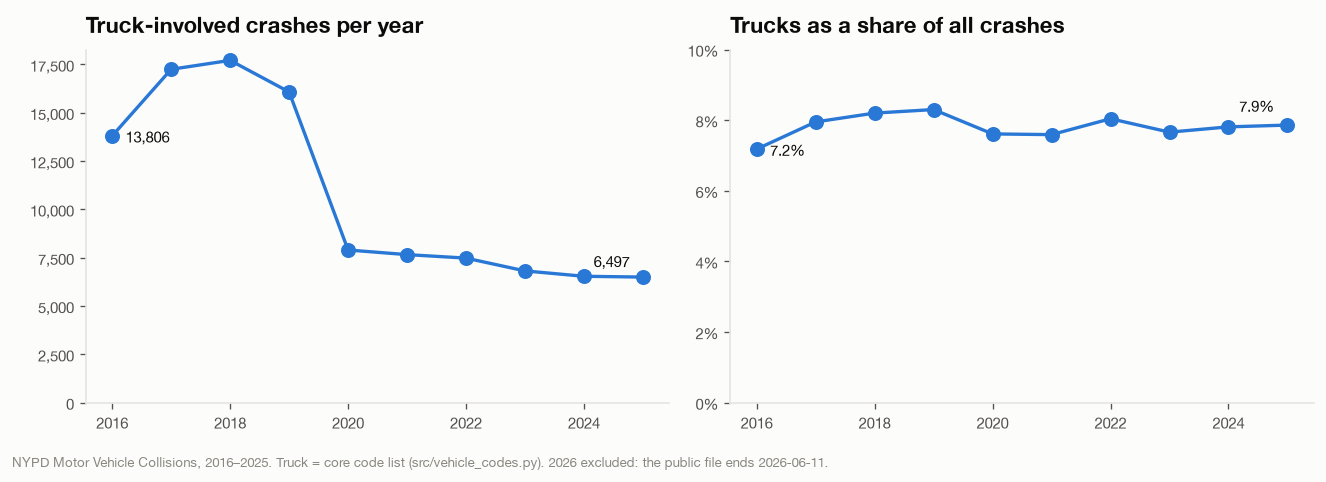

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = viz.strip(axes[0])
ax.plot(full.year, full.truck_crashes, color=viz.BLUE, marker="o")
ax.set_title("Truck-involved crashes per year")
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
for yr, offset, align in ((2016, (8, -4), "left"), (2025, (-8, 6), "right")):
    row = full[full.year == yr].iloc[0]
    ax.annotate(f"{row.truck_crashes:,.0f}", (row.year, row.truck_crashes),
                textcoords="offset points", xytext=offset,
                ha=align, fontsize=9, color=viz.INK)

ax = viz.strip(axes[1])
ax.plot(full.year, full.truck_share_pct, color=viz.BLUE, marker="o")
ax.set_title("Trucks as a share of all crashes")
ax.set_ylim(0, 10)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
for yr, offset, align in ((2016, (8, -4), "left"), (2025, (-8, 8), "right")):
    row = full[full.year == yr].iloc[0]
    ax.annotate(f"{row.truck_share_pct:.1f}%", (row.year, row.truck_share_pct),
                textcoords="offset points", xytext=offset,
                ha=align, fontsize=9, color=viz.INK)

viz.note(fig, "NYPD Motor Vehicle Collisions, 2016–2025. Truck = core code list "
              "(src/vehicle_codes.py). 2026 excluded: the public file ends 2026-06-11.")
plt.tight_layout()
plt.show()

**Truck-involved crashes fell with everything else, and their share of all
crashes did not move.** The count roughly halved — but so did total crashes,
and the share sits in a band of 7.2%–8.3% for the entire decade with no trend.

That stability is itself the finding: whatever drove the citywide decline
(much of it the 2020 collapse in driving) moved trucks and everything else
together. Trucks are involved in about one crash in thirteen, consistently.

### And within trucks — waste specifically?

The core-truck share barely moved over the decade. Does that hold for
waste/refuse trucks on their own? Waste here is `TRUCK_CORE_WASTE` in
`src/vehicle_codes.py` — a subset of the truck list above, read against the
same geocoded population as the three panels already shown, so all four are
directly comparable on one denominator. That is *not* the same denominator as
the citywide refuse-harm series in `research/research-log.md`, which uses the
full (non-geocoded) crash count and the older, narrower `REFUSE` code list —
so the shares below will not match that series exactly, though they tell the
same story.

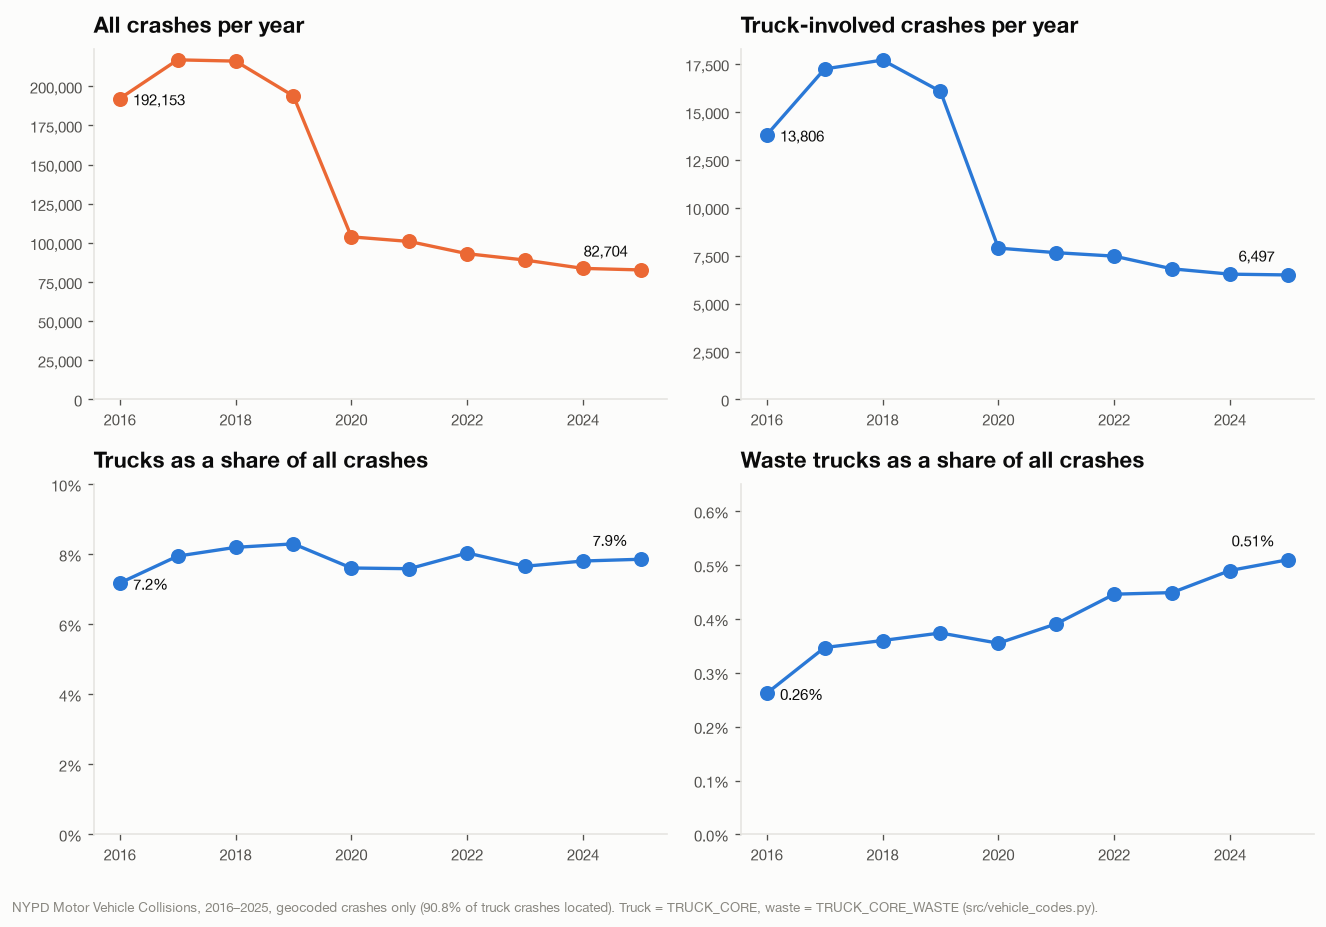

In [16]:
from constants import COMPLIANCE_DEADLINE_YEAR

fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))


def annotate_ends(ax, x, y, fmt):
    """Direct-label the first and last point; the grid carries the rest."""
    for xi, offset, align in ((x.iloc[0], (8, -4), "left"),
                               (x.iloc[-1], (-8, 8), "right")):
        yi = y[x == xi].iloc[0]
        ax.annotate(fmt.format(yi), (xi, yi), textcoords="offset points",
                    xytext=offset, ha=align, fontsize=9, color=viz.INK)


ax = viz.strip(axes[0, 0])
ax.plot(full.year, full.all_crashes, color=viz.ORANGE, marker="o")
ax.set_title("All crashes per year")
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
annotate_ends(ax, full.year, full.all_crashes, "{:,.0f}")

ax = viz.strip(axes[0, 1])
ax.plot(full.year, full.truck_crashes, color=viz.BLUE, marker="o")
ax.set_title("Truck-involved crashes per year")
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
annotate_ends(ax, full.year, full.truck_crashes, "{:,.0f}")

ax = viz.strip(axes[1, 0])
ax.plot(full.year, full.truck_share_pct, color=viz.BLUE, marker="o")
ax.set_title("Trucks as a share of all crashes")
ax.set_ylim(0, 10)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
annotate_ends(ax, full.year, full.truck_share_pct, "{:.1f}%")

ax = viz.strip(axes[1, 1])
ax.plot(full.year, full.waste_share_pct, color=viz.BLUE, marker="o")
#ax.axvline(COMPLIANCE_DEADLINE_YEAR, color=viz.INK_MUTED, linewidth=1,
#           linestyle="--")
#ax.text(COMPLIANCE_DEADLINE_YEAR + 0.15, 0.95, "side-guard\ndeadline",
#        transform=ax.get_xaxis_transform(), ha="left", va="top",
#        fontsize=7.5, color=viz.INK_MUTED)
ax.set_title("Waste trucks as a share of all crashes")
ax.set_ylim(0, 0.65)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.1f}%")
annotate_ends(ax, full.year, full.waste_share_pct, "{:.2f}%")

viz.note(fig, "NYPD Motor Vehicle Collisions, 2016–2025, geocoded crashes only "
              "(90.8% of truck crashes located). Truck = TRUCK_CORE, waste = "
              "TRUCK_CORE_WASTE (src/vehicle_codes.py).", y=-0.02)
plt.tight_layout()
plt.show()

## 2. Where do they happen?

Two maps, because raw density and over-representation answer different
questions. Raw density largely traces where traffic is; the share map shows
where trucks are involved in an *unusual* proportion of crashes.

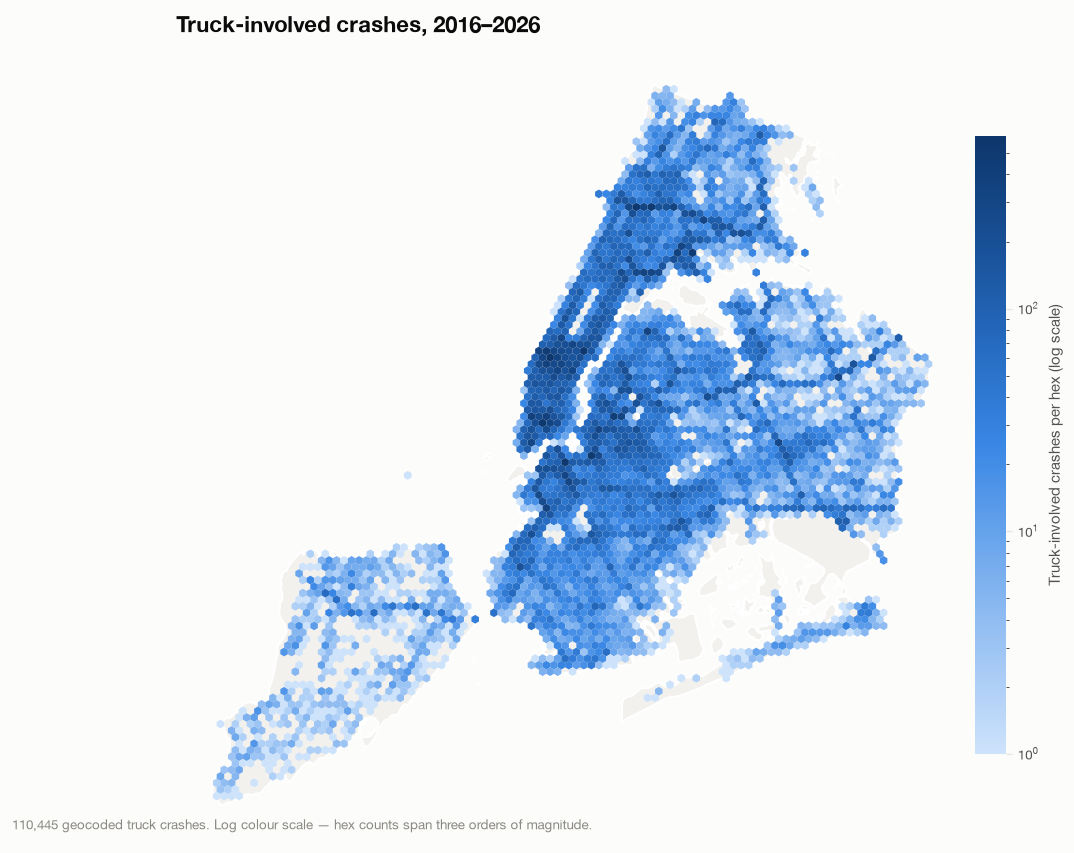

In [17]:
fig, ax = plt.subplots(figsize=(8.8, 7.0), layout="constrained")
viz.map_axes(ax)

boroughs.plot(ax=ax, facecolor="#f2f1ed", edgecolor="#ffffff", linewidth=1.2)
hb = ax.hexbin(truck.x, truck.y, gridsize=95, bins="log",
               cmap=viz.SEQ_CMAP, mincnt=1, linewidths=0.0)

bar = fig.colorbar(hb, ax=ax, shrink=0.78, pad=0.01)
bar.set_label("Truck-involved crashes per hex (log scale)", fontsize=9,
              color=viz.INK_SECONDARY)
bar.outline.set_visible(False)
bar.ax.tick_params(labelsize=8, color=viz.GRID)

ax.set_title("Truck-involved crashes, 2016–2026")
viz.note(fig, f"{len(truck):,} geocoded truck crashes. Log colour scale — hex "
              "counts span three orders of magnitude.", y=0.035)
plt.show()

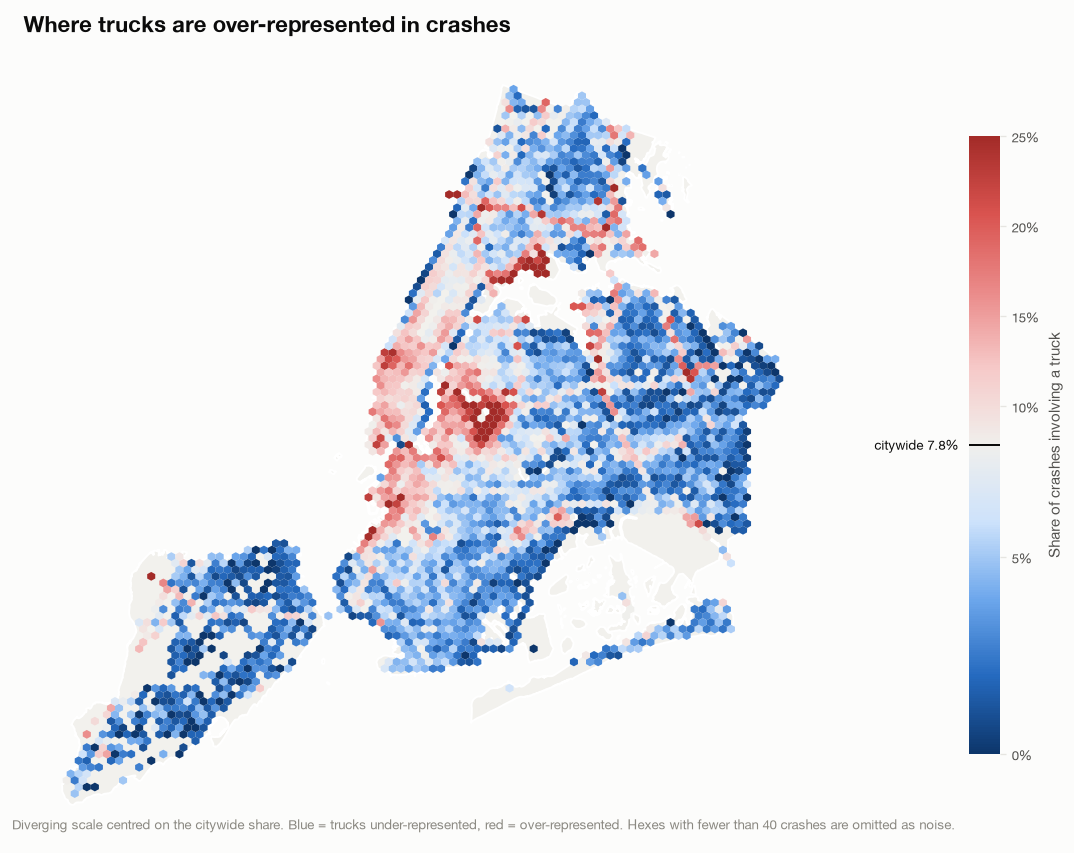

In [18]:
citywide = geo.is_truck_core.mean()

fig, ax = plt.subplots(figsize=(8.8, 7.0), layout="constrained")
viz.map_axes(ax)
boroughs.plot(ax=ax, facecolor="#f2f1ed", edgecolor="#ffffff", linewidth=1.2)

# One hexbin over ALL crashes, coloured by the mean of the truck flag, so each
# hex reads as "what share of crashes here involved a truck". mincnt keeps
# low-volume hexes — where the share is mostly noise — off the map.
hb = ax.hexbin(geo.x, geo.y, C=geo.is_truck_core.astype(float),
               reduce_C_function=np.mean, gridsize=95, mincnt=40,
               cmap=viz.DIV_CMAP,
               norm=TwoSlopeNorm(vmin=0, vcenter=citywide, vmax=0.25),
               linewidths=0.0)

bar = fig.colorbar(hb, ax=ax, shrink=0.78, pad=0.01)
bar.set_label("Share of crashes involving a truck", fontsize=9,
              color=viz.INK_SECONDARY)
bar.outline.set_visible(False)
bar.ax.tick_params(labelsize=8, color=viz.GRID)
bar.ax.axhline(citywide, color=viz.INK, linewidth=1.2)
bar.ax.text(-0.35, citywide, f"citywide {citywide:.1%}", va="center", ha="right",
            fontsize=8, color=viz.INK, transform=bar.ax.get_yaxis_transform())
bar.ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

ax.set_title("Where trucks are over-represented in crashes")
viz.note(fig, "Diverging scale centred on the citywide share. Blue = trucks "
              "under-represented, red = over-represented. Hexes with fewer "
              "than 40 crashes are omitted as noise.", y=0.035)
plt.show()

**Raw density traces traffic; the share map traces freight.** The
over-representation map picks out the industrial and freight geography rather
than the busiest streets: the Bronx's Hunts Point approaches, the Brooklyn
industrial waterfront and Maspeth/Long Island City in Queens, the approaches to
the crossings, and the Staten Island Expressway corridor. Midtown and downtown
Brooklyn, dense with crashes overall, sit at or below the citywide truck share.

## 3. On or off the truck route network?

DOT publishes a network of streets commercial vehicles are required to use.
NYPD geocodes a crash to the roadbed while DOT publishes routes as
centrelines, so a crash genuinely on a route still lands some distance from the
line. **"On-route" is a distance threshold, not a fact in the data** — so the
table reports three.

,group,crashes,on_route_15m,on_route_30m,on_route_50m
0,Truck (core),110445,60.9,62.9,65.0
1,Truck (incl. light commercial),199388,56.9,59.0,61.2
2,No truck involved,1208111,45.0,47.0,49.4
3,All crashes,1407499,46.7,48.7,51.0


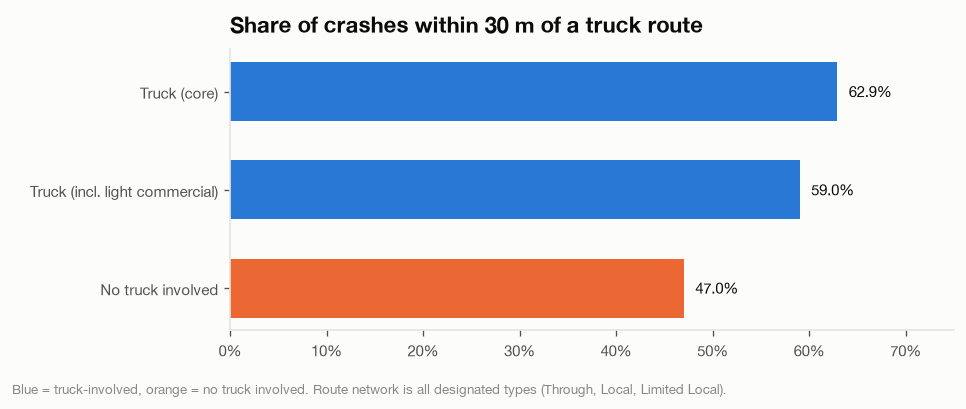

In [19]:
shares = pd.read_csv(PROCESSED_DIR / "route_share.csv")
display(shares)

fig, ax = plt.subplots(figsize=(8, 3.2))
viz.strip(ax, keep_grid="x")

order = ["Truck (core)", "Truck (incl. light commercial)", "No truck involved"]
sub = shares.set_index("group").loc[order]
colors = [viz.BLUE, viz.BLUE, viz.ORANGE]

bars = ax.barh(range(len(sub)), sub[f"on_route_{ROUTE_BUFFER_M}m"],
               color=colors, height=0.6)
ax.set_yticks(range(len(sub)), sub.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 75)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_title(f"Share of crashes within {ROUTE_BUFFER_M} m of a truck route")

for rect, value in zip(bars, sub[f"on_route_{ROUTE_BUFFER_M}m"]):
    ax.text(value + 1.2, rect.get_y() + rect.get_height() / 2, f"{value:.1f}%",
            va="center", fontsize=9, color=viz.INK)

viz.note(fig, "Blue = truck-involved, orange = no truck involved. Route network "
              "is all designated types (Through, Local, Limited Local).")
plt.tight_layout()
plt.show()

,borough,other_share,truck_share,other_n,truck_n,gap_pp
0,BRONX,45.9,58.2,144835,10996,12.3
1,BROOKLYN,34.3,46.6,301064,24302,12.3
2,MANHATTAN,58.7,62.5,169550,21371,3.8
3,QUEENS,40.7,54.9,255792,14332,14.2
4,STATEN ISLAND,65.7,62.6,37074,928,-3.1


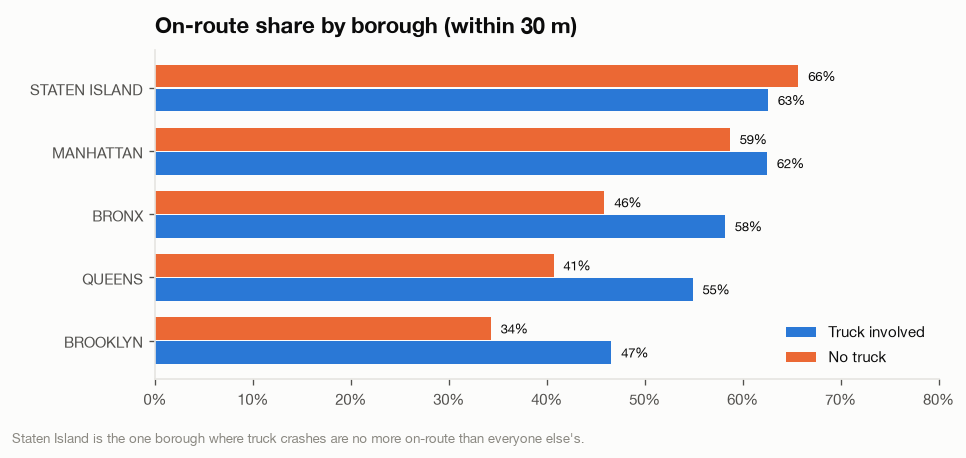

In [20]:
borough = pd.read_csv(PROCESSED_DIR / "route_share_by_borough.csv")
display(borough)

fig, ax = plt.subplots(figsize=(8, 3.6))
viz.strip(ax, keep_grid="x")

b = borough.sort_values("truck_share")
y = np.arange(len(b))
ax.barh(y - 0.19, b.truck_share, height=0.36, color=viz.BLUE, label="Truck involved")
ax.barh(y + 0.19, b.other_share, height=0.36, color=viz.ORANGE, label="No truck")
ax.set_yticks(y, b.borough, fontsize=9)
ax.set_xlim(0, 80)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_title(f"On-route share by borough (within {ROUTE_BUFFER_M} m)")
ax.legend(loc="lower right")

for yi, (t, o) in enumerate(zip(b.truck_share, b.other_share)):
    ax.text(t + 1, yi - 0.19, f"{t:.0f}%", va="center", fontsize=8, color=viz.INK)
    ax.text(o + 1, yi + 0.19, f"{o:.0f}%", va="center", fontsize=8, color=viz.INK)

viz.note(fig, "Staten Island is the one borough where truck crashes are no more "
              "on-route than everyone else's.")
plt.tight_layout()
plt.show()

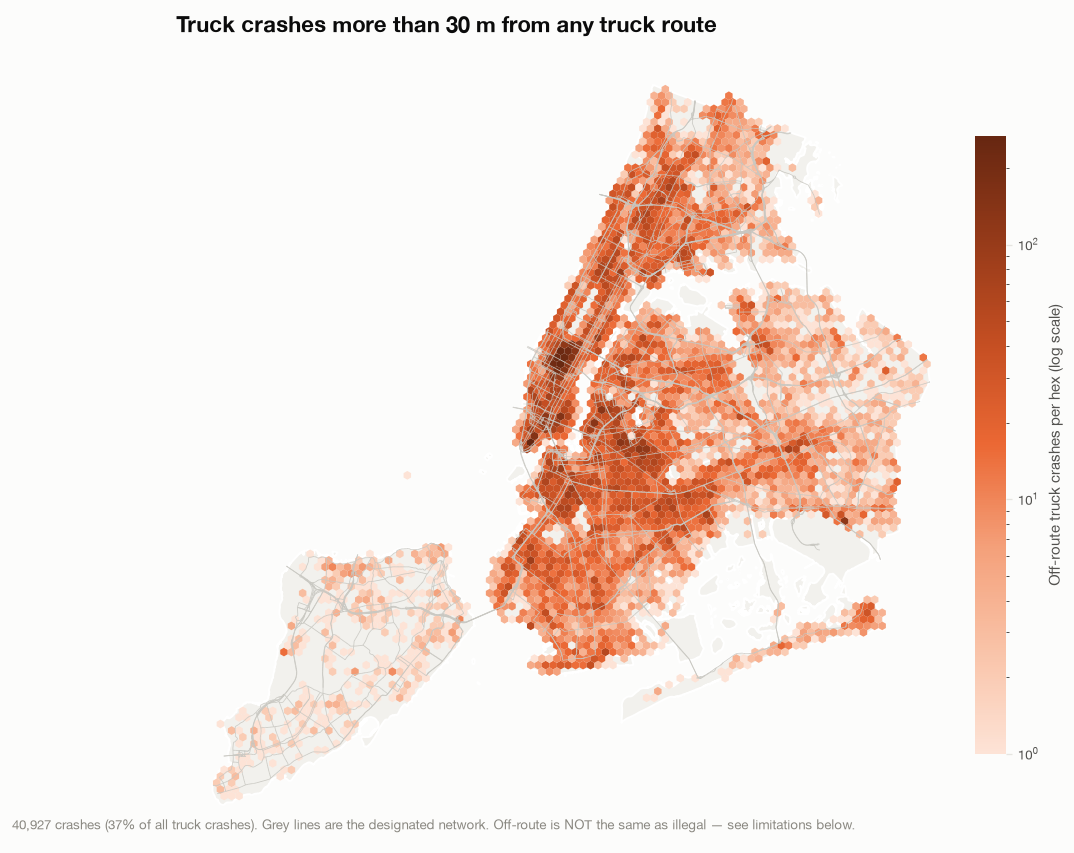

In [21]:
off_route = truck[truck.dist_m > ROUTE_BUFFER_M]

fig, ax = plt.subplots(figsize=(8.8, 7.0), layout="constrained")
viz.map_axes(ax)
boroughs.plot(ax=ax, facecolor="#f2f1ed", edgecolor="#ffffff", linewidth=1.2)
routes.plot(ax=ax, color="#c9c8c2", linewidth=0.45)

hb = ax.hexbin(off_route.x, off_route.y, gridsize=95, bins="log",
               cmap=viz.SEQ_CMAP_ORANGE, mincnt=1, linewidths=0.0)

bar = fig.colorbar(hb, ax=ax, shrink=0.78, pad=0.01)
bar.set_label("Off-route truck crashes per hex (log scale)", fontsize=9,
              color=viz.INK_SECONDARY)
bar.outline.set_visible(False)
bar.ax.tick_params(labelsize=8, color=viz.GRID)

ax.set_title(f"Truck crashes more than {ROUTE_BUFFER_M} m from any truck route")
viz.note(fig, f"{len(off_route):,} crashes ({len(off_route)/len(truck):.0%} of all "
              "truck crashes). Grey lines are the designated network. Off-route "
              "is NOT the same as illegal — see limitations below.", y=0.035)
plt.show()

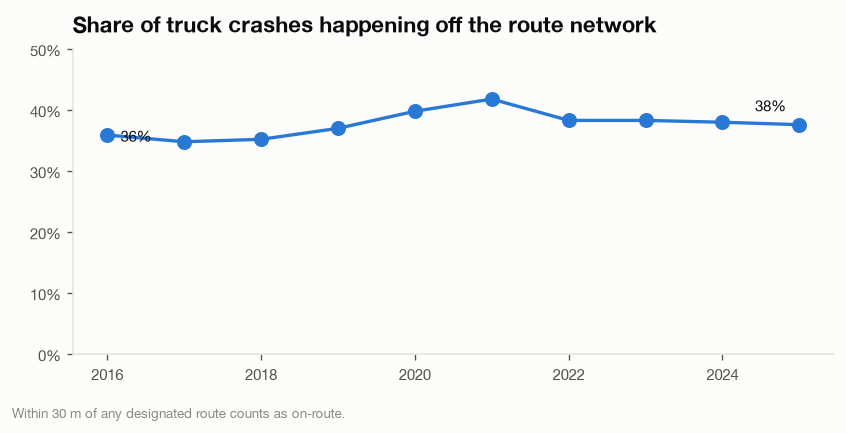

In [22]:
# Does the off-route share move over time?
fig, ax = plt.subplots(figsize=(7, 3.4))
viz.strip(ax)
ax.plot(full.year, full.truck_off_route_pct, color=viz.BLUE, marker="o")
ax.set_ylim(0, 50)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_title("Share of truck crashes happening off the route network")
for yr, offset, align in ((2016, (8, -4), "left"), (2025, (-8, 8), "right")):
    row = full[full.year == yr].iloc[0]
    ax.annotate(f"{row.truck_off_route_pct:.0f}%", (row.year, row.truck_off_route_pct),
                textcoords="offset points", xytext=offset, ha=align,
                fontsize=9, color=viz.INK)
viz.note(fig, f"Within {ROUTE_BUFFER_M} m of any designated route counts as on-route.")
plt.tight_layout()
plt.show()

### What the route comparison shows

**Truck crashes are substantially more concentrated on the route network than
other crashes — and more than a third still happen off it.**

- 62.9% of truck crashes are within 30 m of a designated route, against 47.0%
  of crashes with no truck involved — a 16 percentage point gap.
- The gap holds at every threshold tested (15 m, 30 m, 50 m), so it is not an
  artifact of where the line is drawn.
- It is widest in Queens (+14.2pp), the Bronx and Brooklyn (+12.3pp each), and
  narrow in Manhattan (+3.8pp), where the network covers so much of the street
  grid that being "on-route" says little.
- **Staten Island is the exception**: truck crashes there are marginally *less*
  on-route than other crashes (−3.1pp).
- The off-route share drifted up over the decade, from 35.9% in 2016 to about
  38% now.

**The critical caveat: off-route is not the same as illegal.** Trucks are
permitted to leave the network to reach a destination by the most direct path,
which is most of what local delivery is. This analysis cannot distinguish a
permitted last-mile trip from an illegal shortcut, because nothing in the crash
record says where the truck was going. What the map does show is *where* truck
crashes concentrate away from the designated network — which is the input to
research question 3.

## Limitations specific to this notebook

1. **8.7% of crashes have no usable coordinates** and are dropped from every
   map. Checked for bias: 90.8% of truck crashes are geocoded against 91.4% of
   other crashes — close enough that the on/off-route shares are not
   meaningfully skewed, but the 0.6pp difference is not nothing.
2. **Off-route ≠ illegal.** See above. This is the biggest interpretive risk in
   the notebook.
3. **"Truck" is a curated list over a dirty free-text field.** 2,165 distinct
   `vehicle_type` values exist; 121 cover 99.7% of rows. Some records are
   truncated to five characters (`TRACT`, `BOX T`, `GARBA`) and are folded in.
   The long tail below the cut is excluded by omission.
4. **A crash is counted once regardless of how many trucks are in it**, and
   involvement is not fault. Nothing here says the truck caused the crash.
5. **The route network is the current one**, pulled 2026-09-22. Crashes go back
   to 2016 and the network has changed over that period, so early-year
   on/off-route calls are made against a network that did not yet exist in that
   form. This biases the off-route share for early years in an unknown
   direction, and is a reason to read the time series cautiously.
6. **Hex share maps suppress hexes with fewer than 40 crashes**, so sparse
   industrial areas with genuinely high truck shares may be missing.